# Parallel TWI Computation on Buffered Tiles

For very large areas, running a geospatial operation on the full DEM in
a single pass can be slow or memory-heavy. A common speed-up is to
split the domain into tiles and process each tile independently, but
many operations (D8 flow routing, focal statistics, convolutional
derivatives) are sensitive to the values immediately outside the tile,
so naive tiling introduces edge artifacts where tiles meet.

`get_dem` and `get_map` accept a `buff_npixels` argument that produces
tiles with a small halo of extra pixels around each one. The halo
gives every per-tile operation enough context to compute correct
values in the tile interior, and the overlapping buffers are trimmed
when the per-tile outputs are mosaicked back together.

In this example we compute a Topographic Wetness Index (TWI) over the
St. Vrain HUC-8 by running the [WhiteboxTools](https://www.whiteboxgeo.com/)
pipeline on each buffered DEM tile in parallel, then mosaicking the
per-tile TWI outputs into a single DataArray.

In [1]:
from __future__ import annotations

import shutil
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from tempfile import TemporaryDirectory

import geopandas as gpd
import pywbt

import seamless_3dep as s3dep

Pull the St. Vrain HUC-8 boundary and download buffered DEM tiles in
EPSG:3857 via `get_map`. We add a 10-pixel halo around each tile —
enough room for local flow routing at the tile interior to see real
neighbours on every side.

In [2]:
url = "https://reference.geoconnex.us/collections/hu08/items/10190005"
vrain = gpd.read_file(url)
geom_org = vrain.to_crs(4326).union_all()
geom = vrain.to_crs(3857).buffer(5e3).to_crs(4326).union_all()

data_dir = Path("data")
tiff_files = s3dep.get_map("DEM", geom.bounds, data_dir, 10, buff_npixels=10)

Number of tiles: 6


Define a per-tile TWI function that runs the full WhiteboxTools pipeline
in an isolated temporary directory and returns the path to the TWI
output. Each worker gets its own scratch space so there is no contention
over the intermediate file names.

In [3]:
def compute_twi(dem_path: Path) -> Path:
    twi_path = dem_path.with_name(dem_path.name.replace("dem", "twi"))
    slope_path = dem_path.with_name(dem_path.name.replace("dem", "slope"))
    if twi_path.exists():
        return twi_path
    with TemporaryDirectory(dir=dem_path.parent) as temp:
        shutil.copy(dem_path, temp)
        wbt_args = {
            "BreachDepressions": [f"-i={dem_path.name}", "--fill_pits", "-o=dem_corr.tiff"],
            "D8Pointer": ["-i=dem_corr.tiff", "-o=fdir.tiff"],
            "D8FlowAccumulation": [
                "-i=fdir.tiff",
                "--pntr",
                "--out_type='specific contributing area'",
                "-o=sca.tiff",
            ],
            "Slope": ["-i=dem_corr.tiff", "--units=degrees", f"-o={slope_path.name}"],
            "WetnessIndex": [
                "--sca=sca.tiff",
                f"--slope={slope_path.name}",
                f"-o={twi_path.name}",
            ],
        }
        pywbt.whitebox_tools(temp, wbt_args, [twi_path.name], temp, max_procs=1)
        shutil.copy(Path(temp) / twi_path.name, twi_path)
    return twi_path

Run the per-tile TWI computation in parallel with a thread pool. The
WhiteboxTools work happens in a subprocess so the GIL isn't a limiting
factor here — threads are enough to overlap the per-tile pipelines.

In [4]:
with ThreadPoolExecutor() as executor:
    twi_files = list(executor.map(compute_twi, tiff_files))

Mosaic the per-tile TWI outputs and clip back to the original bounding
box. `tiffs_to_da` builds a VRT over the tiles and `rioxarray.clip_box`
trims the buffered halos so the final array covers exactly the area
originally requested.

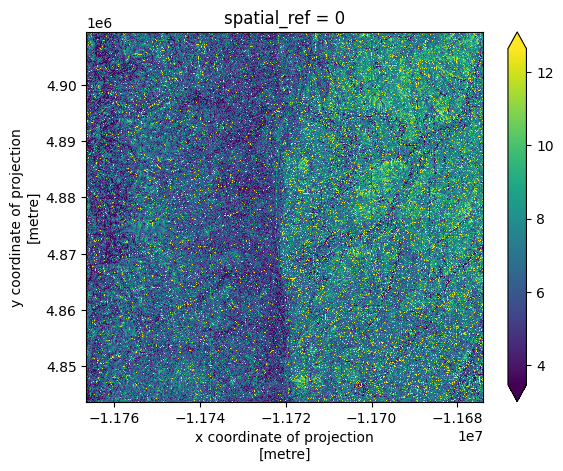

In [5]:
twi = s3dep.tiffs_to_da(twi_files, geom_org.bounds, crs=4326)
ax = twi.plot.imshow(robust=True)
ax.figure.savefig("images/twi.png")